In [1]:
# ============================================================
# BLOCK 1 — Imports
# ============================================================

import pandas as pd
import numpy as np
import pyarrow as pa
import pyarrow.ipc as ipc
import time
import os
import json
import pickle
import tempfile
import matplotlib.pyplot as plt

In [2]:
# ==============================================
# BLOCK 1.5 — Output Directories
# ==============================================

from pathlib import Path

# ------------------------------------------------
# Base project directory
# ------------------------------------------------

BASE_DIR = Path.cwd().parent

# ------------------------------------------------
# Results directories
# ------------------------------------------------

RESULTS_DIR = BASE_DIR / "results" / "ml_pipeline"

GRAPHS_DIR = RESULTS_DIR / "graphs"
TABLES_DIR = RESULTS_DIR / "tables"
LOGS_DIR = RESULTS_DIR / "logs"

# ------------------------------------------------
# Create directories if missing
# ------------------------------------------------

GRAPHS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

TABLES_DIR.mkdir(
    parents=True,
    exist_ok=True
)

LOGS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print(f"Results directory: {RESULTS_DIR}")
# ==============================================
# BLOCK 1.6 — Experiment Metadata
# ==============================================

print("\n" + "="*80)
print("EXPERIMENT CONFIGURATION")
print("="*80)

print(f"Rows               : {1_000_000:,}")
print(f"Formats Tested     : CSV, JSON, Pickle, Parquet, Arrow IPC")
print(f"Output Directory   : {RESULTS_DIR}")



Results directory: /home/megh/arrow-ipc-analysis-linux/results/ml_pipeline


In [3]:
# ============================================================
# BLOCK 2 — Create Synthetic ML Dataset
# ============================================================

print("="*80)
print("CREATING SYNTHETIC ML DATASET")
print("="*80)

n_rows = 1_000_000

df = pd.DataFrame({

    "feature_1": np.random.randn(n_rows),

    "feature_2": np.random.randn(n_rows),

    "feature_3": np.random.randint(
        0,
        1000,
        n_rows
    ),

    "feature_4": np.random.rand(n_rows),

    "category": np.random.choice(
        ["A", "B", "C", "D"],
        n_rows
    )
})

print(df.head())

print(f"\nDataset shape: {df.shape}")

CREATING SYNTHETIC ML DATASET
   feature_1  feature_2  feature_3  feature_4 category
0   0.895918   1.053489        624   0.158706        C
1  -1.077834   0.085807        187   0.319222        B
2   0.876011  -0.769436        416   0.095474        B
3   1.977127  -0.358716        749   0.357590        A
4   0.553184  -1.556615         20   0.892900        C

Dataset shape: (1000000, 5)


In [4]:
# ============================================================
# BLOCK 3 — Temporary Directory
# ============================================================

temp_dir = tempfile.TemporaryDirectory()

temp_path = temp_dir.name

print(f"Temporary path: {temp_path}")

Temporary path: /tmp/tmp4dk21clk


In [5]:
# ============================================================
# BLOCK 4 — Save Dataset in Multiple Formats
# ============================================================

print("="*80)
print("SAVING DATASETS")
print("="*80)

# ------------------------------------------------------------
# CSV
# ------------------------------------------------------------

csv_path = os.path.join(
    temp_path,
    "dataset.csv"
)

df.to_csv(
    csv_path,
    index=False
)

print("CSV saved")

# ------------------------------------------------------------
# JSON
# ------------------------------------------------------------

json_path = os.path.join(
    temp_path,
    "dataset.json"
)

df.to_json(
    json_path,
    orient="records"
)

print("JSON saved")

# ------------------------------------------------------------
# Pickle
# ------------------------------------------------------------

pickle_path = os.path.join(
    temp_path,
    "dataset.pkl"
)

with open(pickle_path, "wb") as f:

    pickle.dump(df, f)

print("Pickle saved")

# ------------------------------------------------------------
# Parquet
# ------------------------------------------------------------

parquet_path = os.path.join(
    temp_path,
    "dataset.parquet"
)

df.to_parquet(
    parquet_path,
    compression=None
)

print("Parquet saved")

# ------------------------------------------------------------
# Arrow IPC
# ------------------------------------------------------------

arrow_path = os.path.join(
    temp_path,
    "dataset.arrow"
)

table = pa.Table.from_pandas(df)

with pa.OSFile(arrow_path, "wb") as sink:

    with ipc.new_file(
        sink,
        table.schema
    ) as writer:

        writer.write_table(table)

print("Arrow IPC saved")

SAVING DATASETS
CSV saved
JSON saved
Pickle saved
Parquet saved
CUSTOM IPC BUILD ACTIVE
Arrow IPC saved


In [6]:
# ============================================================
# BLOCK 5 — ML Preprocessing Simulation
# ============================================================

def preprocessing_pipeline(df):

    # --------------------------------------------------------
    # Select numeric columns
    # --------------------------------------------------------

    X = df[[
        "feature_1",
        "feature_2",
        "feature_3",
        "feature_4"
    ]].to_numpy()

    # --------------------------------------------------------
    # Simulate normalization
    # --------------------------------------------------------

    X = (
        X - X.mean(axis=0)
    ) / X.std(axis=0)

    return X

In [7]:
# ============================================================
# BLOCK 6 — Benchmark Helper
# ============================================================

def benchmark_pipeline(load_func, name):

    # --------------------------------------------------------
    # Measure loading time
    # --------------------------------------------------------

    start = time.perf_counter()

    df_loaded = load_func()

    load_time = time.perf_counter() - start

    # --------------------------------------------------------
    # Measure preprocessing time
    # --------------------------------------------------------

    start = time.perf_counter()

    preprocessing_pipeline(df_loaded)

    preprocess_time = time.perf_counter() - start

    total_time = (
        load_time +
        preprocess_time
    )

    print(
        f"{name:<12} | "
        f"Load: {load_time:.4f}s | "
        f"Preprocess: {preprocess_time:.4f}s | "
        f"Total: {total_time:.4f}s"
    )

    return {
        "Format": name,
        "Load_Time_s": load_time,
        "Preprocess_Time_s": preprocess_time,
        "Total_Pipeline_Time_s": total_time
    }

In [8]:
# ============================================================
# BLOCK 7 — Define Loading Functions
# ============================================================

# ------------------------------------------------------------
# CSV
# ------------------------------------------------------------

def load_csv():

    return pd.read_csv(csv_path)

# ------------------------------------------------------------
# JSON
# ------------------------------------------------------------

def load_json():

    return pd.read_json(json_path)

# ------------------------------------------------------------
# Pickle
# ------------------------------------------------------------

def load_pickle():

    with open(pickle_path, "rb") as f:

        return pickle.load(f)

# ------------------------------------------------------------
# Parquet
# ------------------------------------------------------------

def load_parquet():

    return pd.read_parquet(parquet_path)

# ------------------------------------------------------------
# Arrow IPC
# ------------------------------------------------------------

def load_arrow():

    with pa.memory_map(
        arrow_path,
        "r"
    ) as source:

        reader = ipc.RecordBatchFileReader(source)

        table = reader.read_all()

        return table.to_pandas()

In [9]:
# ============================================================
# BLOCK 8 — Run Benchmarks
# ============================================================

print("\n" + "="*80)
print("RUNNING ML PIPELINE BENCHMARKS")
print("="*80)

results = []

results.append(
    benchmark_pipeline(
        load_csv,
        "CSV"
    )
)

results.append(
    benchmark_pipeline(
        load_json,
        "JSON"
    )
)

results.append(
    benchmark_pipeline(
        load_pickle,
        "Pickle"
    )
)

results.append(
    benchmark_pipeline(
        load_parquet,
        "Parquet"
    )
)

results.append(
    benchmark_pipeline(
        load_arrow,
        "Arrow IPC"
    )
)


RUNNING ML PIPELINE BENCHMARKS
CSV          | Load: 0.5317s | Preprocess: 0.1122s | Total: 0.6439s
JSON         | Load: 2.5214s | Preprocess: 0.0388s | Total: 2.5602s
Pickle       | Load: 0.0171s | Preprocess: 0.0470s | Total: 0.0641s
Parquet      | Load: 0.1022s | Preprocess: 0.0424s | Total: 0.1446s
Arrow IPC    | Load: 0.0104s | Preprocess: 0.0419s | Total: 0.0523s


In [10]:
# ============================================================
# BLOCK 9 — Results Table
# ============================================================

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="Total_Pipeline_Time_s"
)

print("\n" + "="*80)
print("FINAL RESULTS")
print("="*80)

results_df


FINAL RESULTS


,Format,Load_Time_s,Preprocess_Time_s,Total_Pipeline_Time_s
4,Arrow IPC,0.010401,0.041872,0.052274
2,Pickle,0.017129,0.046998,0.064127
3,Parquet,0.102216,0.042358,0.144574
0,CSV,0.531679,0.112197,0.643876
1,JSON,2.521394,0.038839,2.560234


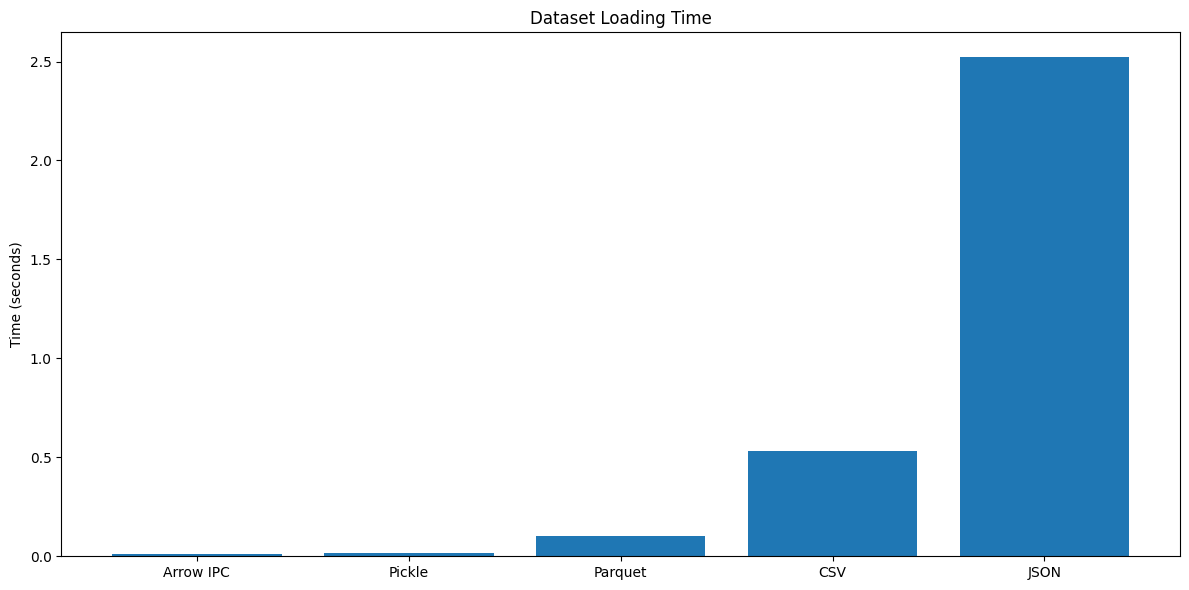

In [11]:
# ==============================================
# BLOCK 10 — Loading Time Visualization
# ==============================================

plt.figure(figsize=(12, 6))

plt.bar(
    results_df["Format"],
    results_df["Load_Time_s"]
)

plt.title("Dataset Loading Time")

plt.ylabel("Time (seconds)")

plt.tight_layout()

plt.savefig(
    GRAPHS_DIR / "loading_time.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


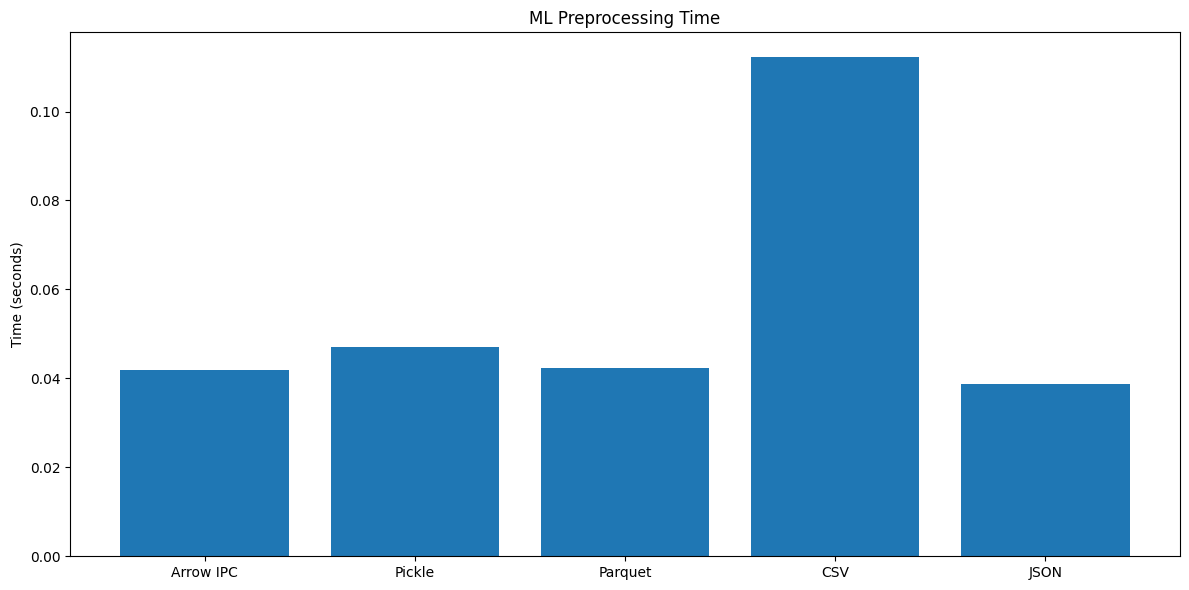

In [13]:
# ==============================================
# BLOCK 11 — Preprocessing Time Visualization
# ==============================================

plt.figure(figsize=(12, 6))

plt.bar(
    results_df["Format"],
    results_df["Preprocess_Time_s"]
)

plt.title("ML Preprocessing Time")

plt.ylabel("Time (seconds)")

plt.tight_layout()

plt.savefig(
    GRAPHS_DIR / "preprocessing_time.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


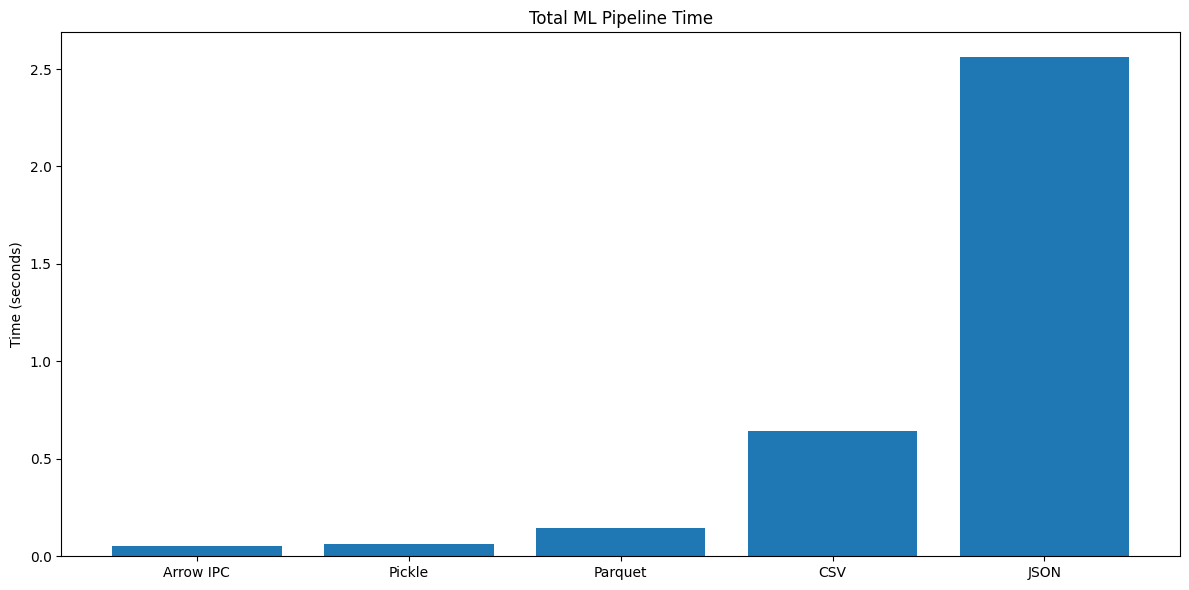

In [14]:
# ==============================================
# BLOCK 12 — Total Pipeline Time Visualization
# ==============================================

plt.figure(figsize=(12, 6))

plt.bar(
    results_df["Format"],
    results_df["Total_Pipeline_Time_s"]
)

plt.title("Total ML Pipeline Time")

plt.ylabel("Time (seconds)")

plt.tight_layout()

plt.savefig(
    GRAPHS_DIR / "total_pipeline_time.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


In [15]:
# ============================================================
# BLOCK 13 — Save Results
# ============================================================
results_csv_path = ( TABLES_DIR / "ml_pipeline_results.csv" )
results_df.to_csv( results_csv_path, index=False ) 
print( f"\nResults saved to:\n{results_csv_path}" )


Results saved to:
/home/megh/arrow-ipc-analysis-linux/results/ml_pipeline/tables/ml_pipeline_results.csv


In [16]:
# ============================================================
# BLOCK 14 — Cleanup
# ============================================================

temp_dir.cleanup()

print("\nTemporary files cleaned up.")


Temporary files cleaned up.
